The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


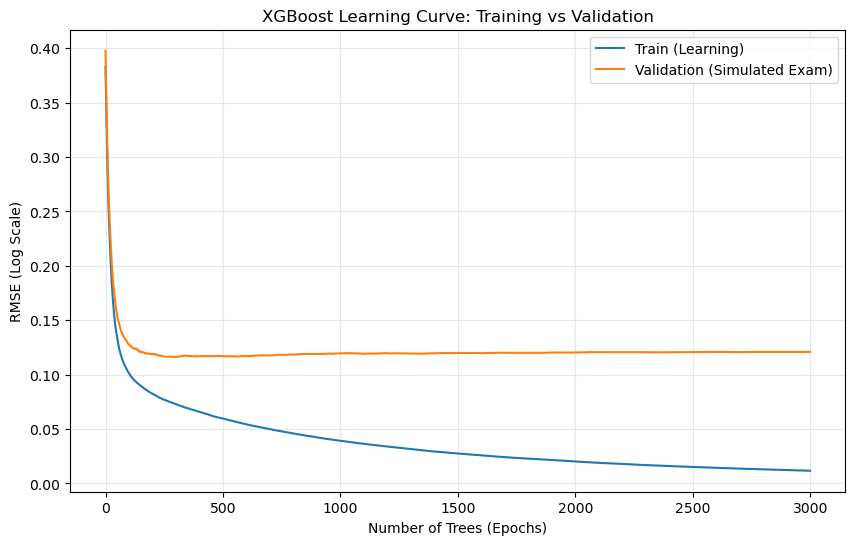

D:\Kaggle-Learning\01-Getting-Started\House-Prices\notebooks\..\src\visualize.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_importance, palette='viridis')


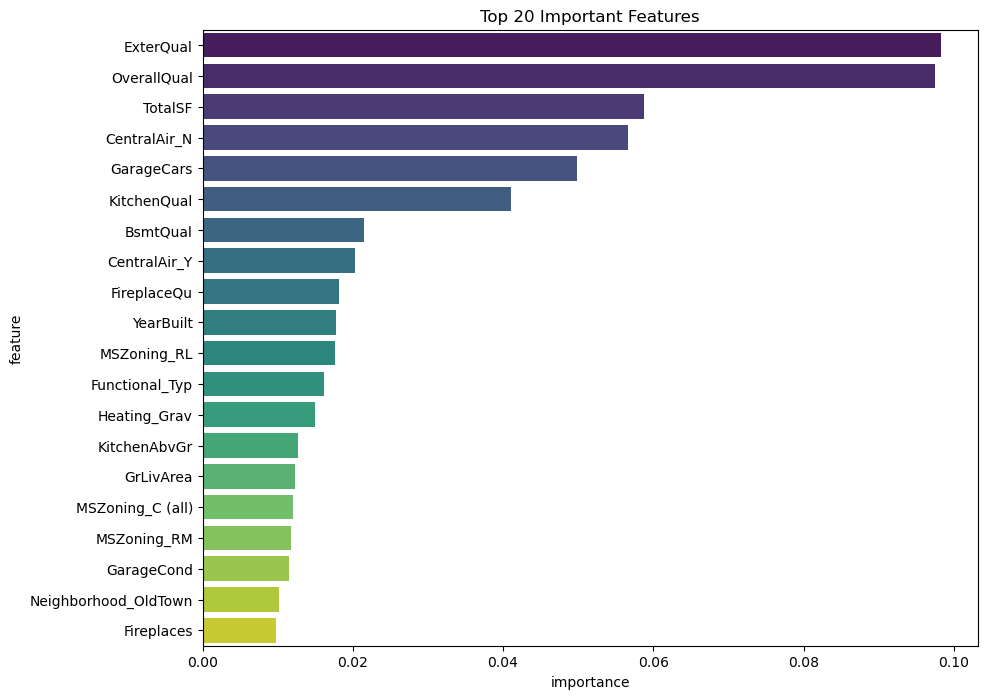

In [17]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import pandas as pd
import numpy as np
from src.processing import preprocess_data
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb
from src.visualize import plot_xgb_learning_curve, plot_feature_importance

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
train = train.drop(outliers).reset_index(drop=True)
train_final, test_final = preprocess_data(train, test)

X = train_final.drop(['SalePrice', 'Id'], axis=1)
y = train_final['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model_xgb = xgb.XGBRegressor(
    learning_rate=0.05,      # 步长中等，兼顾速度和精度
    n_estimators=3000,       # 足够多的树，配合早停使用
    max_depth=3,             # 限制深度，防止在小样本上过拟合
    min_child_weight=3,    # 每个叶子节点所需的最小权重和
    gamma=0,                 # 基础分裂阈值
    subsample=0.5,           # 每次只用 70% 的数据，增加鲁棒性
    colsample_bytree=0.5,    # 每次只用 70% 的特征
    reg_alpha=0.00006,       # 轻微的 L1 正则
    n_jobs=-1,               # 调用所有cpu核心
    eval_metric="rmse",
    random_state=42
)

# 训练并在 eval_set 中记录
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

plot_xgb_learning_curve(model_xgb)
plot_feature_importance(model_xgb)

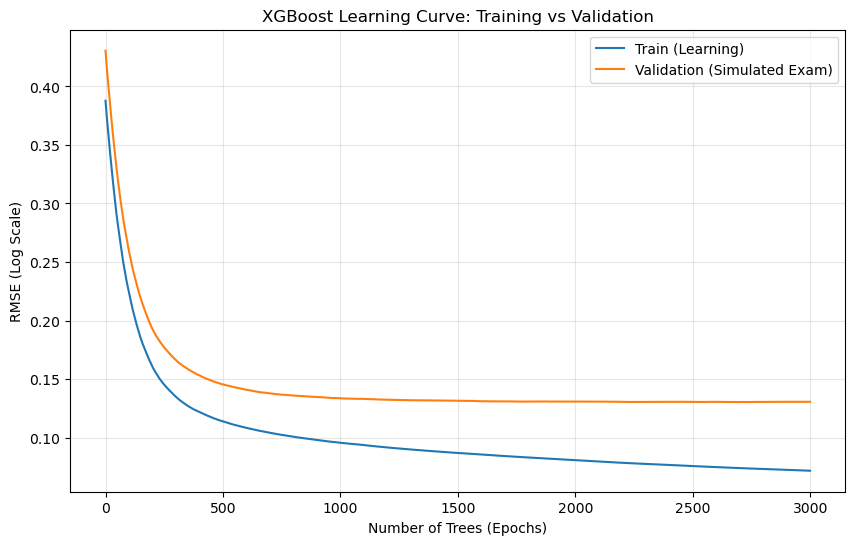

D:\Kaggle-Learning\01-Getting-Started\House-Prices\notebooks\..\src\visualize.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_importance, palette='viridis')


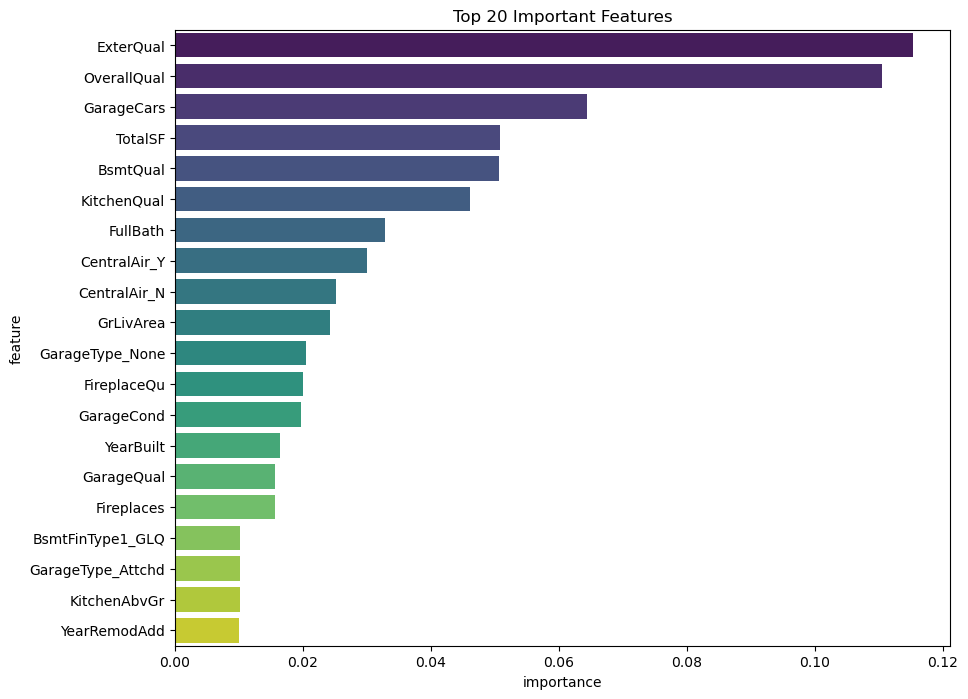

In [7]:
model_xgb_A = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01, 
    max_depth=3,           # 降到3，最稳健的深度
    subsample=0.5,         # 只看一半的样本
    colsample_bytree=0.3,  # 重点：每次只看 30% 的特征
    min_child_weight=5,    # 增加约束
    reg_alpha=0.5,         # 增加 L1 正则
    eval_metric="rmse",
)

model_xgb_A.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

plot_xgb_learning_curve(model_xgb_A)
plot_feature_importance(model_xgb_A)

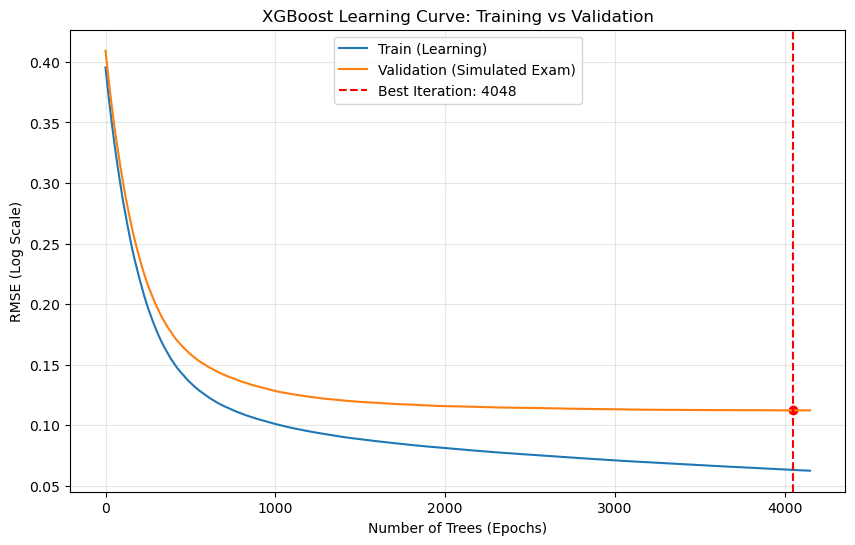

最佳树的数量是: 4048


In [18]:
model_xgb_B = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.005,   # 极低学习率
    max_depth=3,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_lambda=1.5,        # 增加 L2 正则
    eval_metric="rmse",
    early_stopping_rounds=100
)

model_xgb_B.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

plot_xgb_learning_curve(model_xgb_B)
print(f"最佳树的数量是: {model_xgb_B.best_iteration}")

In [20]:
# 1. 拿到刚才实验得出的最佳迭代次数
best_n = model_xgb_B.best_iteration

# 2. 重新定义模型（去掉 early_stopping，设置 n_estimators 为 best_n）
final_model = xgb.XGBRegressor(
    n_estimators=best_n,    # 关键：不再是 5000，而是实验得出的那个数
    learning_rate=0.005,
    max_depth=3,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_lambda=1.5
)

# 3. 用全量数据训练 (不再需要 eval_set)
final_model.fit(X, y)

# 4. 预测
X_test = test_final.drop(['Id'], axis=1)[X.columns] # 确保特征顺序一致
predictions = np.expm1(final_model.predict(X_test))

# 5. 保存
submission = pd.DataFrame({"Id": test_final["Id"], "SalePrice": predictions})
submission.to_csv('../submissions/xgboost_submission_v2.csv', index=False)